In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Статистические характеристики изображений

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


image.shape: (720, 1080, 3)
image_gray.shape: (720, 1080)
image_gray[0,0]: 129


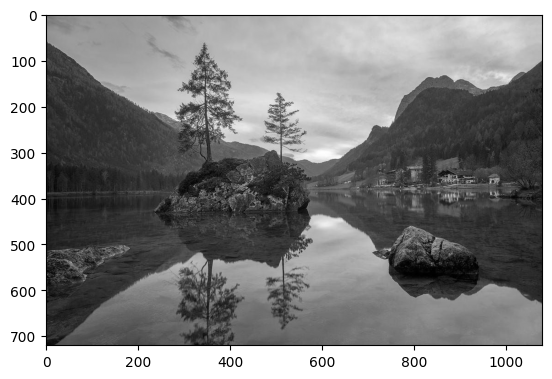

In [66]:
  #  Задание 1
image = cv2.imread('/content/izb.jpg')

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("image.shape:", image.shape)
print("image_gray.shape:", image_gray.shape)
print("image_gray[0,0]:", image_gray[0,0])

plt.imshow(image_gray, cmap='gray')
plt.show()

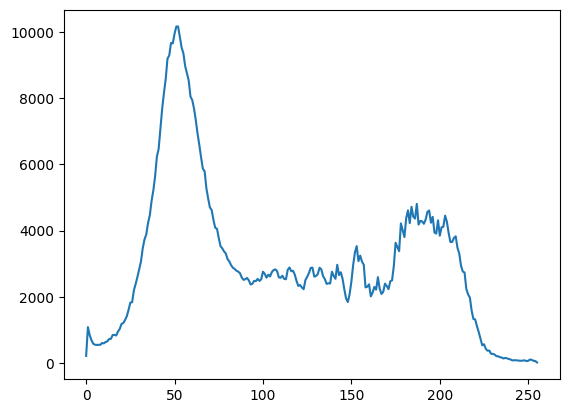

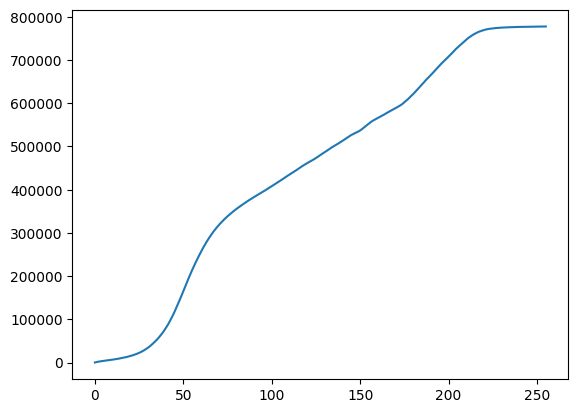

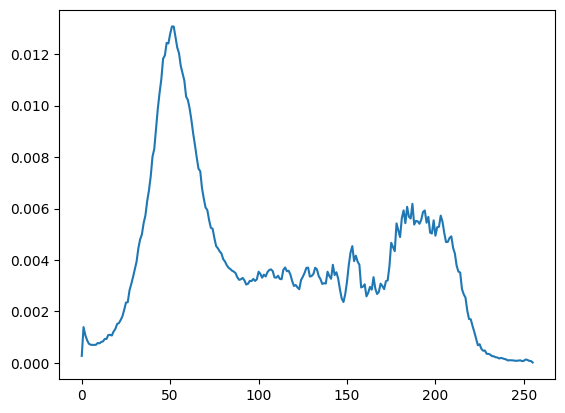

In [67]:
#  Задание 2
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)
gray_hist_cum = gray_hist.cumsum()
gray_hist_norm = gray_hist / (image_gray.shape[0] * image_gray.shape[1])

plt.plot(gray_hist)
plt.show()

plt.plot(gray_hist_cum)
plt.show()

plt.plot(gray_hist_norm)
plt.show()


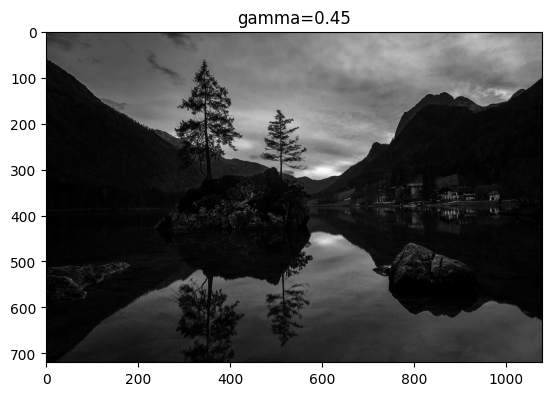

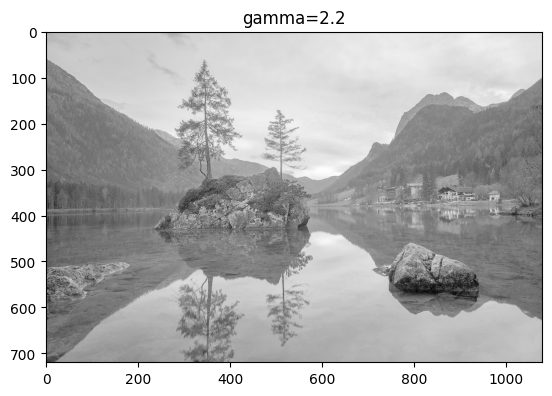

In [68]:
#  Задание 3
def gamma_correction(img, gamma):
    inv = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img, table)

gamma_low  = gamma_correction(image_gray, 0.45)
gamma_high = gamma_correction(image_gray, 2.2)

plt.imshow(gamma_low, cmap='gray');  plt.title("gamma=0.45"); plt.show()
plt.imshow(gamma_high, cmap='gray'); plt.title("gamma=2.2");  plt.show()



gamma=0.45 | SSIM = 0.5423 | MSE = 3117.49
gamma=2.2  | SSIM = 0.8249 | MSE = 3464.88


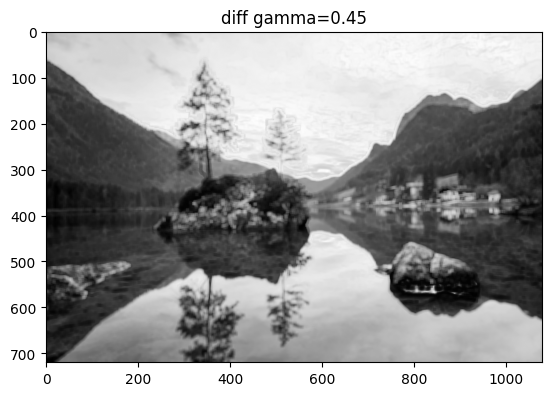

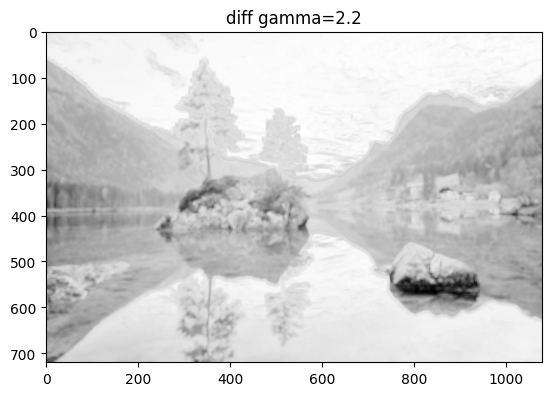

In [69]:
#  Задание 4
(ssim_low,  diff_low)  = structural_similarity(image_gray, gamma_low,  full=True)
(ssim_high, diff_high) = structural_similarity(image_gray, gamma_high, full=True)
mse_low  = mean_squared_error(image_gray, gamma_low)
mse_high = mean_squared_error(image_gray, gamma_high)

print("gamma=0.45 | SSIM = {:.4f} | MSE = {:.2f}".format(ssim_low,  mse_low))
print("gamma=2.2  | SSIM = {:.4f} | MSE = {:.2f}".format(ssim_high, mse_high))

plt.imshow((diff_low * 255).astype("uint8"), cmap='gray');  plt.title("diff gamma=0.45"); plt.show()
plt.imshow((diff_high * 255).astype("uint8"), cmap='gray'); plt.title("diff gamma=2.2");  plt.show()

eq_gray mean/std: 128.2050257201646 73.41047178534033
stat_gray mean/std: 127.49664994855966 73.02186289382773


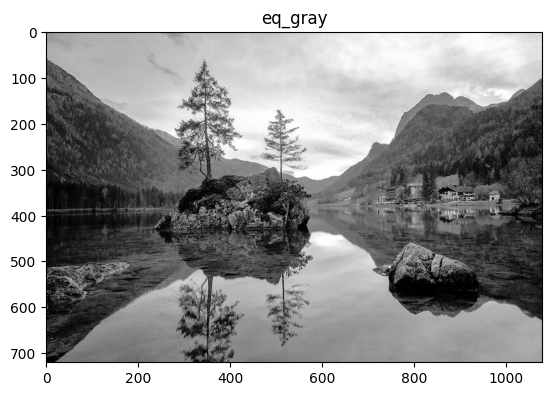

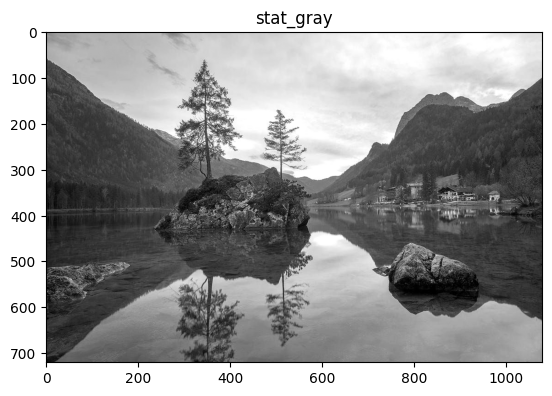

stat vs eq | SSIM = 0.9035 | MSE = 173.02


In [70]:
#  Задание 5
eq_gray = cv2.equalizeHist(image_gray)

mean = eq_gray.mean()
std  = eq_gray.std()
print("eq_gray mean/std:", mean, std)

def stat_color_correction(img, target_mean, target_std):
    src_mean = img.mean()
    src_std  = img.std()
    out = (img.astype(np.float32) - src_mean) * (target_std / src_std) + target_mean
    return np.clip(out, 0, 255).astype(np.uint8)

stat_gray = stat_color_correction(image_gray, mean, std)
print("stat_gray mean/std:", stat_gray.mean(), stat_gray.std())

plt.imshow(eq_gray,   cmap='gray'); plt.title("eq_gray");   plt.show()
plt.imshow(stat_gray, cmap='gray'); plt.title("stat_gray"); plt.show()

(ssim_stat, diff_stat) = structural_similarity(eq_gray, stat_gray, full=True)
mse_stat = mean_squared_error(eq_gray, stat_gray)
print("stat vs eq | SSIM = {:.4f} | MSE = {:.2f}".format(ssim_stat, mse_stat))

THRESH_BINARY T=60 | white = 67.04%


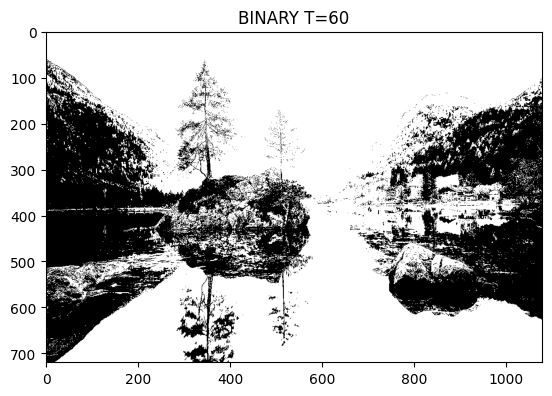

THRESH_BINARY T=100 | white = 47.53%


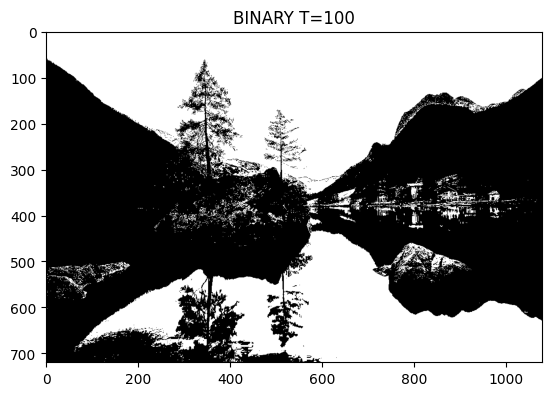

THRESH_BINARY T=150 | white = 30.94%


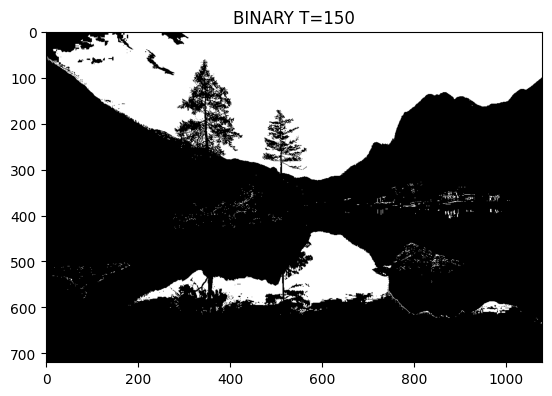

THRESH_BINARY T=200 | white = 8.97%


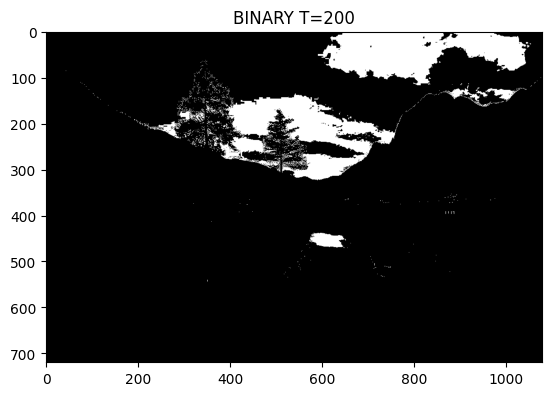

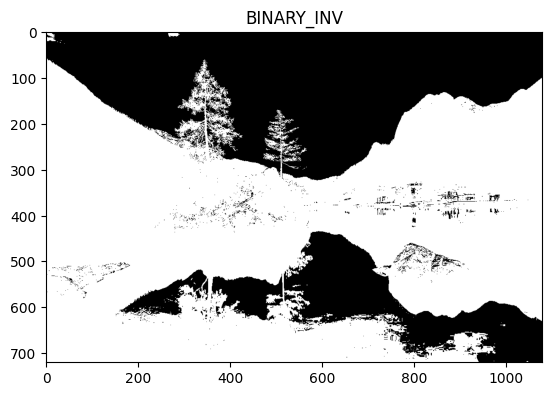

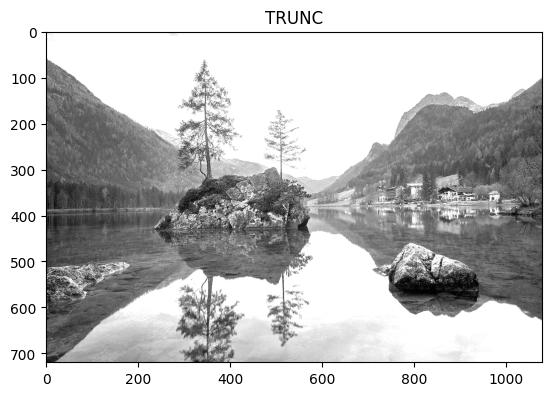

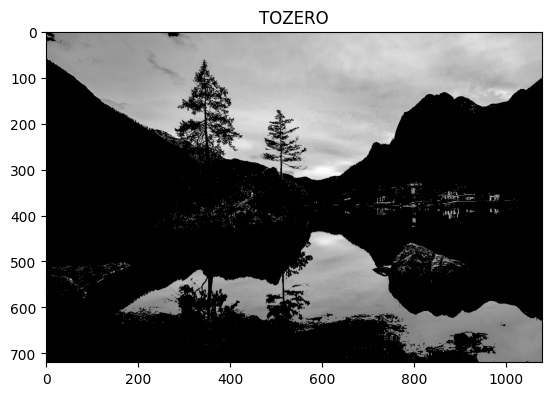

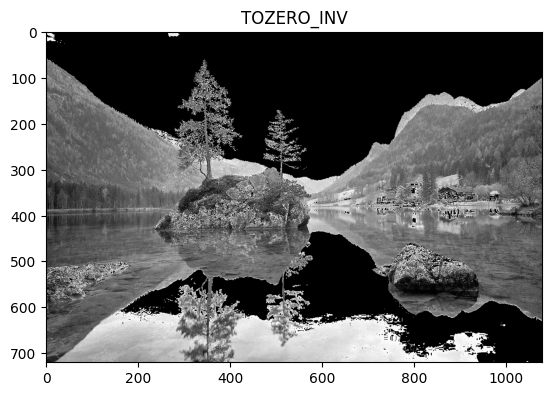

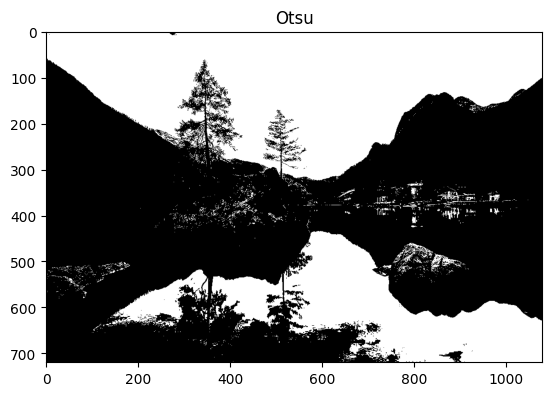

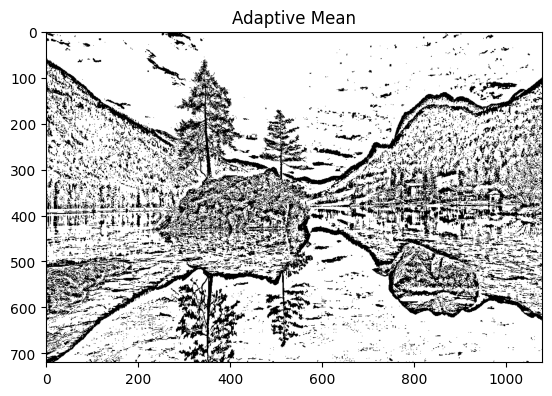

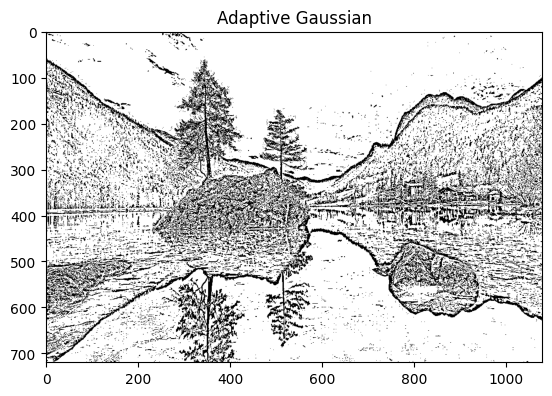

In [71]:
#  Задание 6
for t in [60, 100, 150, 200]:
    _, thresh = cv2.threshold(image_gray, t, 255, cv2.THRESH_BINARY)
    print("THRESH_BINARY T={} | white = {:.2%}".format(t, np.mean(thresh > 0)))
    plt.imshow(thresh, cmap='gray'); plt.title("BINARY T={}".format(t)); plt.show()

for name, m in [("BINARY_INV", cv2.THRESH_BINARY_INV),
                ("TRUNC",      cv2.THRESH_TRUNC),
                ("TOZERO",     cv2.THRESH_TOZERO),
                ("TOZERO_INV", cv2.THRESH_TOZERO_INV)]:
    _, thresh = cv2.threshold(image_gray, 127, 255, m)
    plt.imshow(thresh, cmap='gray'); plt.title(name); plt.show()

_, otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsu, cmap='gray'); plt.title("Otsu"); plt.show()

adapt_mean  = cv2.adaptiveThreshold(image_gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 21, 5)
adapt_gauss = cv2.adaptiveThreshold(image_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 5)

plt.imshow(adapt_mean,  cmap='gray'); plt.title("Adaptive Mean");     plt.show()
plt.imshow(adapt_gauss, cmap='gray'); plt.title("Adaptive Gaussian"); plt.show()